In [1]:
import pennylane as qp
qml = qp
import numpy as np

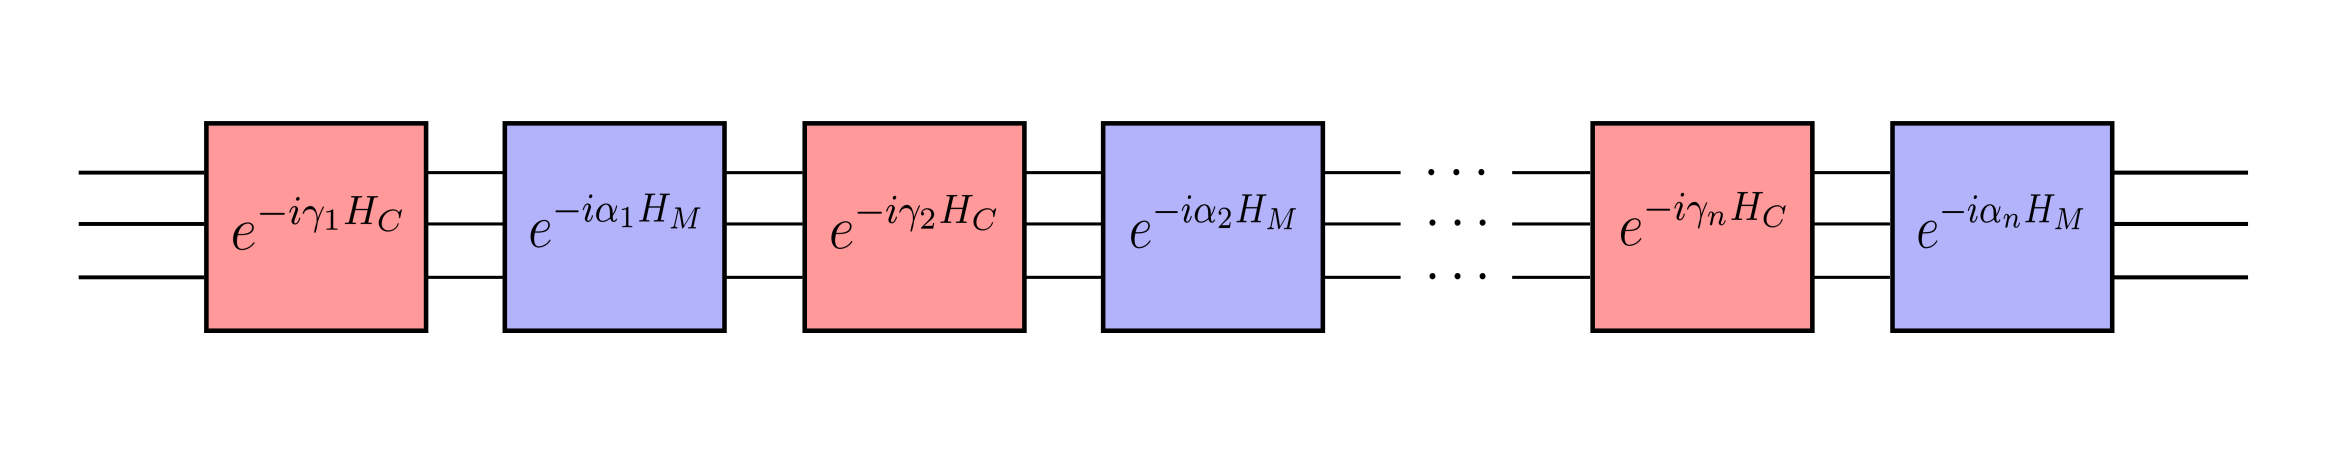

In [2]:
n_wires = 1
dev = qp.device("default.qubit", wires=n_wires)
p = 3
cost_h = qp.Hamiltonian([1], [qp.PauliZ(0)])
mixer_h = qp.Hamiltonian([1], [qp.PauliX(0)])
params = qp.numpy.ones((p, 2),requires_grad=True) * 0.5

def qaoa_layer(params, cost_h):
    """Implement one QAOA layer alternating H_C and H_M.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    qp.qaoa.cost_layer(params[0], cost_h)
    qp.qaoa.mixer_layer(params[1], mixer_h)

def qaoa_circuit(params, p, cost_h):
    """Implement the initial state and p layers of the QAOA ansatz.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    for i in range(n_wires):
        qp.Hadamard(wires=i)
    for i in range(p):
        qaoa_layer(params[i], cost_h)

@qp.qnode(dev)
def probability_circuit(params, p, cost_h):
    """QAOA circuit which returns the probabilities.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    Returns:
        (np.tensor): A tensor with the probabilities of measuring the quantum states.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    qaoa_circuit(params, p, cost_h)

    return qp.probs(wires=range(n_wires))

In [3]:
n_wires = 1
dev = qp.device("default.qubit", wires=n_wires)
p =  3
cost_h = qp.Hamiltonian([1], [qp.PauliZ(0)])
mixer_h = qp.Hamiltonian([1], [qp.PauliX(0)])
params = qp.numpy.ones((p, 2),requires_grad=True) * 0.5

def optimizer(params, p, cost_h):
    """Optimizer to adjust the parameters.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qp.Hamiltonian): The cost Hamiltonian
        
    Returns:
        (np.array): An array with the optimized parameters of the QAOA ansatz.
    """      
    optimizer = qp.AdamOptimizer(0.1)
    steps = 100
    for _ in range(steps):
        params, _ , _ = optimizer.step(cost_function, params, p, cost_h)
        
    return params

@qp.qnode(dev)
def cost_function(params, p, cost_h):
    """Cost function of the QAOA circuit.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.

    Returns: 
        (np.tensor): A 1 dimensional tensor with the expected value of the cost Hamiltonian after applying the QAOA circuit.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    qaoa_circuit(params, p, cost_h)
    
    return qp.expval(cost_h)

def execute_QAOA(params, p, cost_h):
    """Execute QAOA Algorithm.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qp.Hamiltonian): The cost Hamiltonian

    Returns:
        (np.tensor): A tensor with the final probabilities of measuring the quantum states.
        (np.array): The optimized parameters of the QAOA.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    best_params = optimizer(params, p, cost_h)
    probs = probability_circuit(best_params, p, cost_h)
    
    return probs, best_params

In [4]:
n_particles = 3
n_wires = n_particles
h_list = [1, 2, -3]
# Define the mixer Hamiltonian
mixer_h = qp.Hamiltonian([1.0] * n_wires, [qp.PauliX(i) for i in range(n_wires)])
# Define number of layers and initial parameters
p = 5
params = qp.numpy.ones((p, 2), requires_grad=True) * 0.5

dev = qp.device('default.qubit', wires = n_wires)

def qaoa_layer(params, cost_h):
    """Implement one QAOA layer alternating H_C and H_M.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """
    qp.qaoa.cost_layer(params[0], cost_h)
    qp.qaoa.mixer_layer(params[1], mixer_h)

def qaoa_circuit(params, p, cost_h):
    """Implement the initial state and p layers of the QAOA ansatz.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """  
    for i in range(n_wires):
        qp.Hadamard(wires=i)
    for i in range(p):
        qaoa_layer(params[i], cost_h)

@qp.qnode(dev)
def cost_function(params, p, cost_h):
    """Cost function of the QAOA circuit.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.

    Returns: 
        (np.tensor): A 1 dimensional tensor with the expected value of the cost Hamiltonian after applying the QAOA circuit.
    """  
    qaoa_circuit(params, p, cost_h)
    
    return qp.expval(cost_h)

@qp.qnode(dev)
def probability_circuit(params, p, cost_h):
    """QAOA circuit which returns the probabilities.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    Returns:
        (np.tensor): A tensor with the probabilities of measuring the quantum states.
    """  
    qaoa_circuit(params, p, cost_h)

    return qp.probs(wires=range(n_wires))

def build_cost_ising(n_particles, h_list):
    """Function to build the cost Hamiltonian of the Longitudinal Ising problem.
    
    Args:
        n_particles (int): Number of particles to be considered in the Hamiltonian.
        h_list (list[float]): List of magnetic field values for each particle.
        
    Returns:
        (qp.Hamiltonian): The cost Hamiltonian of the Longitudinal Ising model.
    """
    ##################
    # YOUR CODE HERE #
    ##################
    obs = [qp.PauliZ(i) @ qp.PauliZ(i + 1) for i in range(n_particles - 1)] + [qp.PauliZ(i) for i in range(n_particles)]
    coeffs = [-1] * (n_particles - 1) + [-h for h in h_list]
    
    return qp.Hamiltonian(coeffs, obs)

def QAOA_ising(params, p, cost_h):
    """QAOA Algorithm to solve the Longitudinal Ising problem.
    Args:
        params (np.array): an array with the trainable parameters of the QAOA ansatz.
        p (int): number of layers of the QAOA ansatz.
        cost_h (qp.Hamiltonian): the cost Hamiltonian.
        
    Returns:
        (np.tensor): a tensor with the final probabilities of measuring the quantum states.
        (np.array): the optimized parameters of the QAOA.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    best_params = optimizer(params, p, cost_h)
    probs = probability_circuit(best_params, p, cost_h)
    
    return probs, best_params

In [5]:
cost_h = build_cost_ising(n_particles, h_list)
QAOA_ising(params, p, cost_h)

(tensor([7.41070286e-04, 9.96446933e-01, 8.72852353e-05, 4.32013342e-04,
         5.55004543e-04, 6.85316210e-04, 2.06495959e-05, 1.03172732e-03], requires_grad=True),
 tensor([[0.47553658, 0.27173432],
         [0.47258923, 1.08379829],
         [0.39910951, 0.72230436],
         [0.29341579, 0.63986454],
         [0.64999041, 0.950464  ]], requires_grad=True))

In [6]:
numbers = [1, 3, 4, 7, 13]
total_sum = sum(numbers)
# Number of qubits needed (each number is represented by a qubit)
n_wires = len(numbers)
# Define the mixer Hamiltonian
mixer_h = qp.Hamiltonian([1.0] * n_wires, [qp.PauliX(i) for i in range(n_wires)])
dev = qp.device('default.qubit', wires = n_wires)
# Define the hyperparameters for the optimizer:
p = 20
params = qp.numpy.ones((p, 2),requires_grad=True) * 0.5
step_size = 0.001
max_steps = 150

def qaoa_layer(params, cost_h):
    """Implement one QAOA layer alternating H_C and H_M.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """
    qp.qaoa.cost_layer(params[0], cost_h)
    qp.qaoa.mixer_layer(params[1], mixer_h)

def qaoa_circuit(params, p, cost_h):
    """Implement the initial state and p layers of the QAOA ansatz.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    """  
    for i in range(n_wires):
        qp.Hadamard(wires=i)
    for i in range(p):
        qaoa_layer(params[i], cost_h)

@qp.qnode(dev)
def cost_function(params, p, cost_h):
    """Cost function of the QAOA circuit.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.

    Returns: 
        (np.tensor): A 1 dimensional tensor with the expected value of the cost Hamiltonian after applying the QAOA circuit.
    """  
    qaoa_circuit(params, p, cost_h)
    
    return qp.expval(cost_h)

@qp.qnode(dev)
def probability_circuit(params, p, cost_h):
    """QAOA circuit which returns the probabilities.
    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        cost_h (qml.Hamiltonian): The cost Hamiltonian
    Returns:
        (np.tensor): A tensor with the probabilities of measuring the quantum states.
    """  
    qaoa_circuit(params, p, cost_h)

    return qp.probs(wires=range(n_wires))

def build_cost_number_partition(numbers):
    """Function to build the cost Hamiltonian of a number partition problem.

    Args:
        numbers (list): A list with the numbers we want to divide in two groups with equal sums.
        
    Returns:
        (qp.Hamiltonian): The cost Hamiltonian of the number partition problem
    """      
    ##################
    # YOUR CODE HERE #
    ##################
    coeffs = [numbers[i] * numbers[j]
              for i in range(n_wires)
              for j in range(n_wires)]

    obs = [
        qp.Identity(0) if i == j
        else qp.PauliZ(i) @ qp.PauliZ(j)
        for i in range(n_wires)
        for j in range(n_wires)
    ]
    
    return qp.Hamiltonian(coeffs, obs)

def optimizer_number_partition(params, p, step_size, max_steps, cost_h):
    """Optimizer to adjust the parameters.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        step_size (float): Learning rate of the gradient descent optimizer
        max_steps (int): Number of iterations of the optimizer.
        cost_h (qp.Hamiltonian): The cost Hamiltonian.

    Returns:
        (np.array): An array with the optimized parameters of the QAOA ansatz.
    """      
    optimizer = qp.AdamOptimizer(step_size) 
    for _ in range(max_steps):
        params, _, _ = optimizer.step(cost_function, params, p, cost_h)
        
    return params

def QAOA_number_partition(params, p, step_size, max_steps, cost_h):
    """QAOA Algorithm to solve the number partition problem.

    Args:
        params (np.array): An array with the trainable parameters of the QAOA ansatz.
        p (int): Number of layers of the QAOA ansatz.
        step_size (float): Learning rate of the gradient descent optimizer
        max_steps (int): Number of iterations of the optimizer.
        cost_h (qp.Hamiltonian): The cost Hamiltonian.

    Returns:
        (np.tensor): A tensor with the final probabilities of measuring the quantum states.
        (np.array): The optimized parameters of the QAOA.
    """  
    ##################
    # YOUR CODE HERE #
    ##################
    best_params = optimizer_number_partition(params, p, step_size, max_steps, cost_h)
    probs = probability_circuit(best_params, p, cost_h)
    
    return probs, best_params

In [7]:
cost_h = build_cost_number_partition(numbers)
QAOA_number_partition(params, p, step_size, max_steps, cost_h)

(tensor([2.52626698e-05, 3.82906154e-03, 2.24628968e-05, 2.57504350e-05,
         3.07013615e-06, 6.00597614e-03, 7.00763490e-03, 3.02469663e-05,
         4.52595007e-05, 8.97704380e-03, 2.12209589e-04, 3.47886912e-05,
         4.87384620e-05, 8.26997882e-05, 4.73645522e-01, 4.27270286e-06,
         4.27270286e-06, 4.73645522e-01, 8.26997882e-05, 4.87384620e-05,
         3.47886912e-05, 2.12209589e-04, 8.97704380e-03, 4.52595007e-05,
         3.02469663e-05, 7.00763490e-03, 6.00597614e-03, 3.07013615e-06,
         2.57504350e-05, 2.24628968e-05, 3.82906154e-03, 2.52626698e-05], requires_grad=True),
 tensor([[0.50238718, 0.50340612],
         [0.50448313, 0.50174066],
         [0.49740995, 0.51442976],
         [0.50123489, 0.4843276 ],
         [0.50306582, 0.48428287],
         [0.49821795, 0.50049403],
         [0.50227342, 0.4574014 ],
         [0.49722304, 0.50399577],
         [0.49933004, 0.50285217],
         [0.49857222, 0.48635964],
         [0.49641453, 0.51378574],
         